In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV


In [2]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
for i in df.columns: 
    print(df[i].value_counts())

Car_Name
city                  26
corolla altis         16
verna                 14
fortuner              11
brio                  10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64
Year
2015    61
2016    50
2014    38
2017    35
2013    33
2012    23
2011    19
2010    15
2008     7
2009     6
2005     4
2006     4
2007     2
2003     2
2018     1
2004     1
Name: count, dtype: int64
Selling_Price
0.45     8
0.60     8
4.50     7
5.25     7
4.75     6
        ..
10.11    1
6.40     1
8.55     1
9.50     1
11.50    1
Name: count, Length: 156, dtype: int64
Present_Price
9.40     14
13.60    13
5.70      8
1.47      7
4.43      6
         ..
6.10      1
13.09     1
11.60     1
11.00     1
12.50     1
Name: count, Length: 148, dtype: int64
Driven_kms
15000    9
45000    9
40000    5
25000    5
50000    5
        ..
60076    1
33988    1
87934    1
90

In [6]:
# Feature Engineering

df['Mileage']= df['Driven_kms'] # Mileage/Usage = Driven_kms
df['Age'] = df['Year'].max() - df['Year'] # Age = Current_year-Year_of_manufacture | Current_year = maximum of recoreded year, because the others values are of that year's

In [7]:
# Finding of Brand Goodwill 

df['Depriciation Rate'] = df['Selling_Price'] / df['Present_Price'] # Depriciation Rate = ratio between Selling price and Presend price
# Brands with high "goodwill" typically have a lower depreciation rate

In [8]:
Brand_Grouping = (df['Selling_Price'].groupby(df['Car_Name']).mean()).sort_values(ascending=False)

In [9]:
# Band Grouping 

df['Brand_Grouping'] = df['Car_Name'].map(Brand_Grouping)

In [10]:
# Adding column Horse_power 

hp_map = {
    # Maruti/Suzuki
    'ritz': 85, 'sx4': 103, 'ciaz': 91, 'wagon r': 67, 'swift': 82,
    'vitara brezza': 89, 's cross': 103, 'alto 800': 48, 'alto k10': 67,
    'dzire': 82, 'ertiga': 91, 'ignis': 83, 'baleno': 83, 'omni': 37,
    '800': 37,
    # Toyota
    'fortuner': 177, 'innova': 136, 'corolla altis': 140, 'etios cross': 90,
    'etios g': 90, 'etios liva': 90, 'etios gd': 68, 'corolla': 120,
    'camry': 178, 'land cruiser': 235,
    # Royal Enfield
    'royal enfield thunder 500': 27, 'royal enfield thunder 350': 19,
    'royal enfield classic 350': 20, 'royal enfield classic 500': 27,
    'royal enfield bullet 350': 19,
    # KTM
    'ktm rc200': 25, 'ktm rc390': 43, 'ktm 390 duke': 43,
    # Bajaj
    'bajaj dominar 400': 35, 'bajaj pulsar rs200': 24, 'bajaj avenger 220': 19,
    'bajaj avenger 150': 15, 'bajaj avenger street 220': 19,
    'bajaj avenger 220 dtsi': 19, 'bajaj avenger 150 street': 15,
    'bajaj pulsar 150': 14, 'bajaj pulsar ns 200': 23, 'bajaj pulsar  ns 200': 23,
    'bajaj pulsar 220 f': 21, 'bajaj pulsar 135 ls': 13,
    'bajaj discover 100': 9, 'bajaj discover 125': 11, 'bajaj  ct 100': 8,
    # UM / Hyosung / Mahindra
    'um renegade mojave': 45, 'hyosung gt250r': 28, 'mahindra mojo xt300': 27,
    # Honda (bikes)
    'honda cb hornet 160r': 15, 'honda cbr 150': 17, 'honda cb trigger': 14,
    'honda cb unicorn': 13, 'honda karizma': 17, 'honda cb twister': 10,
    'honda cb shine': 11, 'honda dream yuga': 11, 'honda activa 4g': 8,
    'honda activa 125': 9,
    # Yamaha
    'yamaha fz s v 2.0': 14, 'yamaha fz 16': 14, 'yamaha fz  v 2.0': 14,
    'yamaha fz s': 13, 'yamaha fazer': 14,
    # TVS
    'tvs apache rtr 160': 15, 'tvs apache rtr 180': 17,
    'tvs jupyter': 7, 'tvs wego': 7, 'tvs sport': 7,
    # Hero
    'hero extreme': 14, 'hero splender ismart': 11, 'hero passion pro': 10,
    'hero passion x pro': 10, 'hero splender plus': 10,
    'hero honda cbz extreme': 14, 'hero hunk': 15,
    'hero  ignitor disc': 11, 'hero  cbz xtreme': 14,
    'hero honda passion pro': 10, 'hero glamour': 11, 'hero super splendor': 10,
    # Suzuki (bikes)
    'suzuki access 125': 8,
    # Activa
    'activa 3g': 8, 'activa 4g': 8,
    # Hyundai
    'i20': 82, 'grand i10': 69, 'i10': 55, 'eon': 55, 'xcent': 83,
    'elantra': 148, 'creta': 121, 'verna': 105,
    # Honda (cars)
    'city': 119, 'brio': 87, 'amaze': 87, 'jazz': 98,
}

def get_hp(name):
    key = name.strip().lower()
    if key in hp_map:
        return hp_map[key]
    for model, hp in hp_map.items():
        if model in key or key in model:
            return hp
    return None

df['Horsepower'] = df['Car_Name'].apply(get_hp).fillna(0).astype(int)

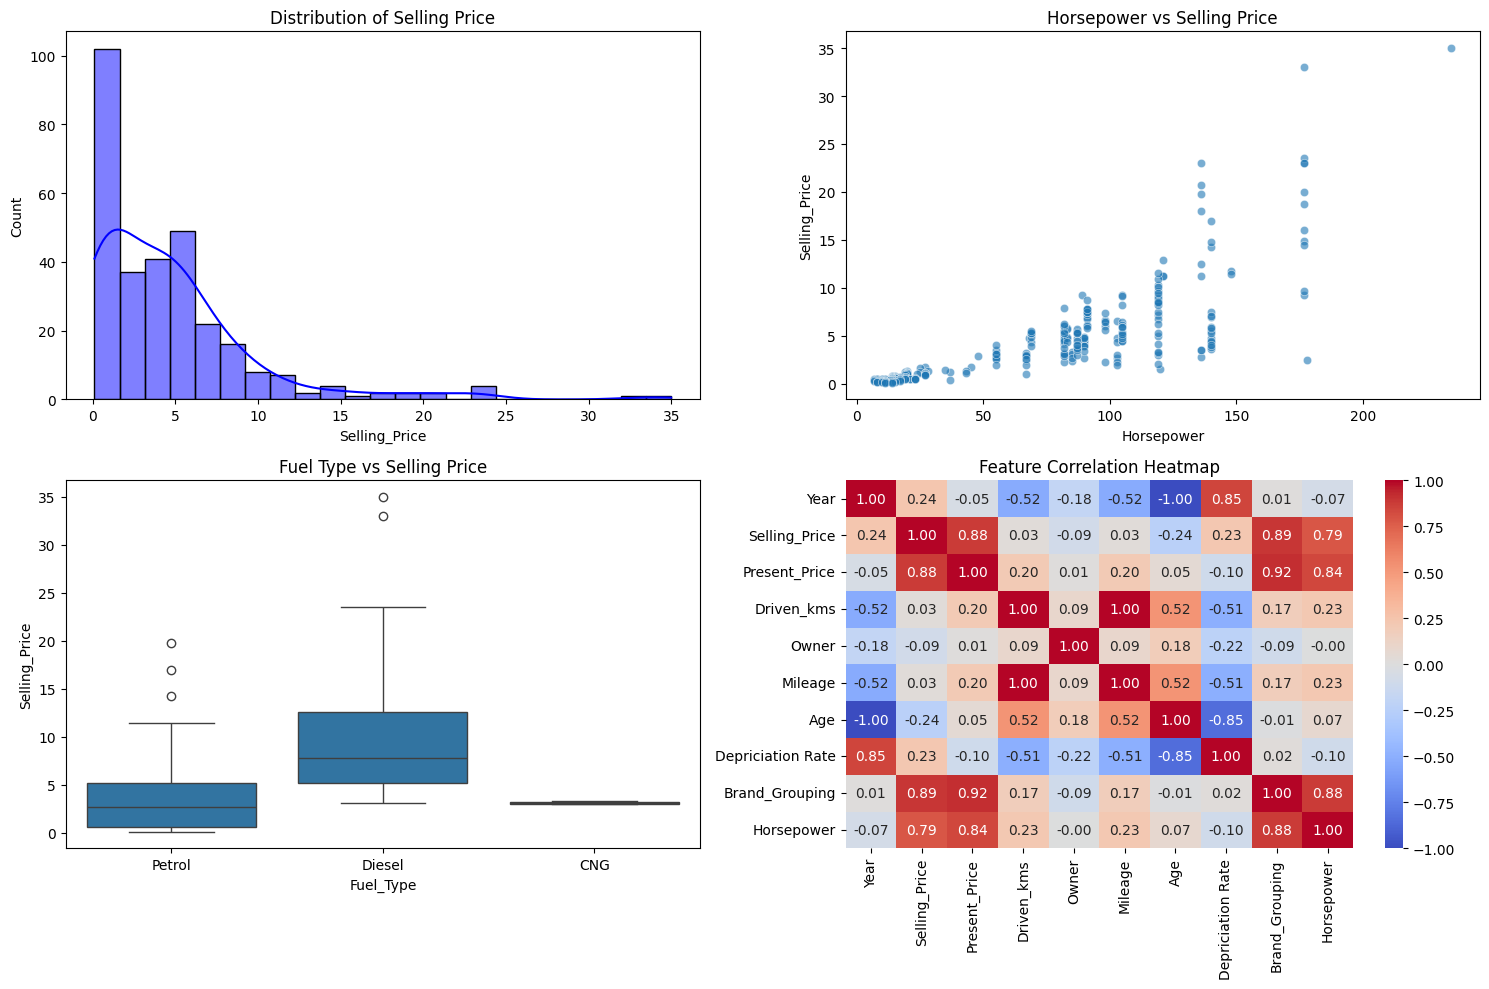

In [11]:
plt.figure(figsize=(15, 10))

# 1. Distribution of Selling Price
plt.subplot(2, 2, 1)
sns.histplot(df['Selling_Price'], kde=True, color='blue')
plt.title('Distribution of Selling Price')

# 2. Relationship between Horsepower and Selling Price
plt.subplot(2, 2, 2)
sns.scatterplot(x='Horsepower', y='Selling_Price', data=df, alpha=0.6)
plt.title('Horsepower vs Selling Price')

# 3. Fuel Type vs Selling Price (Boxplot)
plt.subplot(2, 2, 3)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title('Fuel Type vs Selling Price')

# 4. Correlation Heatmap (Numeric only)
plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

#### Insights : 
* Distribution of selling price has a Positive Skewness.
* Selling Price increases with the Horse power. That means It is an important pricing factor
* Selling Price of Diesel car is most ther Petrol and CNG consequently. That says, Diesel and Petrol car is mostly used and the contains very little number of outlier
* Selling price have highly positive correlated with Present price, brand grouping and Horse Power, and moderately corelated with Year. 

C:\Users\AKIB\AppData\Local\Temp\ipykernel_5140\952619892.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Transmission', y='Selling_Price', data=df, palette='Set2')


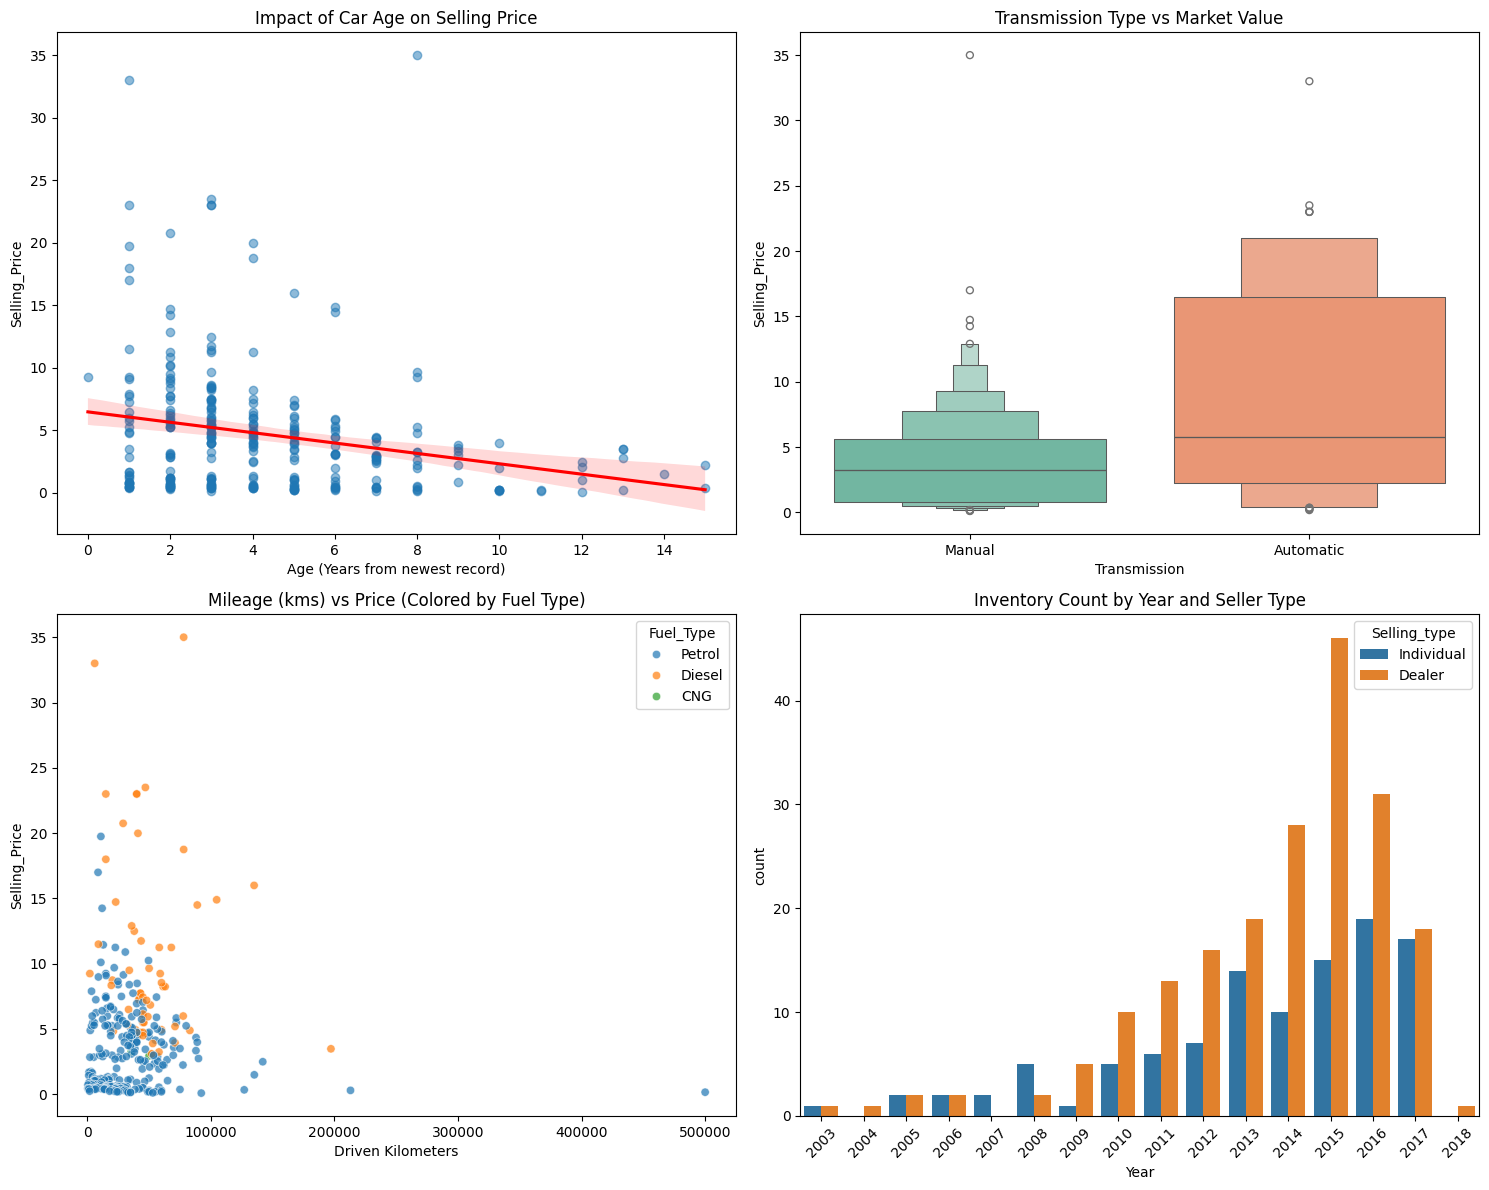

In [12]:
# 1. Age vs Selling Price with Regression Line
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
sns.regplot(x='Age', y='Selling_Price', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Impact of Car Age on Selling Price')
plt.xlabel('Age (Years from newest record)')

# 2. Transmission Type vs Selling Price (Boxenplot for distribution detail)
plt.subplot(2, 2, 2)
sns.boxenplot(x='Transmission', y='Selling_Price', data=df, palette='Set2')
plt.title('Transmission Type vs Market Value')

# 3. Driven KMs vs Selling Price (Log Scale for better visibility of spread)
plt.subplot(2, 2, 3)
sns.scatterplot(x='Driven_kms', y='Selling_Price', hue='Fuel_Type', data=df, alpha=0.7)
plt.title('Mileage (kms) vs Price (Colored by Fuel Type)')
plt.xlabel('Driven Kilometers')

# 4. Count of Cars by Year and Selling Type
plt.subplot(2, 2, 4)
sns.countplot(x='Year', hue='Selling_type', data=df)
plt.title('Inventory Count by Year and Seller Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Insights : 
* Selling price is decreased with the age comperatively. That means selling price will decrease more of same type of car in the future.
* Automated car is more expensive than Manual car.
* Most of the Petrols cars selling price is Less than the Diesel car
* In 2003 Individual Inventory Car and Dealer Inventory Car sells equally, But as the day passes Dealer Inventory car's sell increasing rapidly till 2015, after than the rapidness decresses.

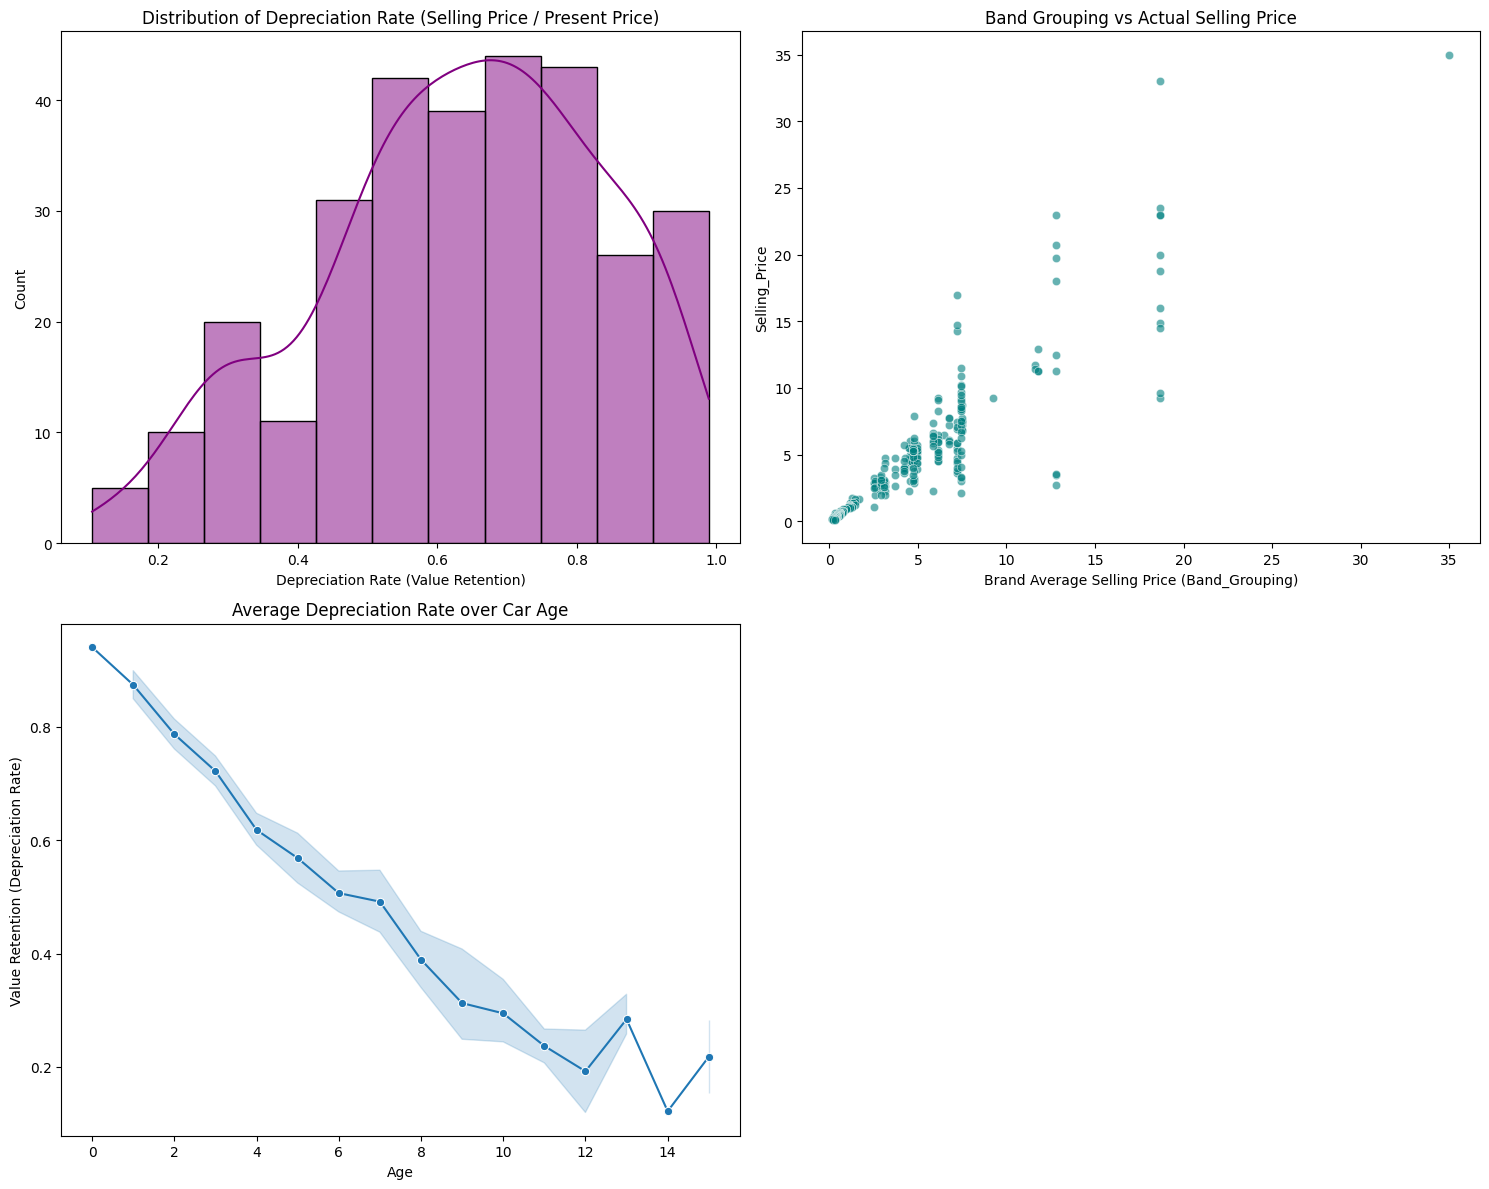

In [13]:
plt.figure(figsize=(15,12))

# 1. Visualization of Depreciation Rate
plt.subplot(2, 2, 1)
sns.histplot(df['Depriciation Rate'], kde=True, color='purple')
plt.title('Distribution of Depreciation Rate (Selling Price / Present Price)')
plt.xlabel('Depreciation Rate (Value Retention)')

# 2. Band Grouping vs Selling Price
plt.subplot(2, 2, 2)
sns.scatterplot(x='Brand_Grouping', y='Selling_Price', data=df, alpha=0.6, color='teal')
plt.title('Band Grouping vs Actual Selling Price')
plt.xlabel('Brand Average Selling Price (Band_Grouping)')

# 3. Correlation between Depreciation and Age
plt.subplot(2, 2, 3)
sns.lineplot(x='Age', y='Depriciation Rate', data=df, marker='o')
plt.title('Average Depreciation Rate over Car Age')
plt.ylabel('Value Retention (Depreciation Rate)')

plt.tight_layout()
plt.show()

#### Insights : 
* Distribution of Depreciation Rate has Negative Skewness.
* Selling price is increasing with the Brand Grouping.
* Depreciation Rate is decreasing with the Age

## Data Preprocessing

In [14]:
unique_counts = {}
for i in df.columns:
    unique_counts[i] = df[i].unique().shape[0] 

unique_counts

{'Car_Name': 98,
 'Year': 16,
 'Selling_Price': 156,
 'Present_Price': 148,
 'Driven_kms': 206,
 'Fuel_Type': 3,
 'Selling_type': 2,
 'Transmission': 2,
 'Owner': 3,
 'Mileage': 206,
 'Age': 16,
 'Depriciation Rate': 273,
 'Brand_Grouping': 77,
 'Horsepower': 45}

In [15]:
# Encoding

df['Fuel_Type'] = df['Fuel_Type'].map({'Petrol':0, 'Diesel':1, 'CNG':2})
df['Selling_type'] = df['Selling_type'].map({'Dealer':0, 'Individual':1})
df['Transmission'] = df['Transmission'].map({'Manual':0, 'Automatic':1})

In [16]:
df.head(3)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Mileage,Age,Depriciation Rate,Brand_Grouping,Horsepower
0,ritz,2014,3.35,5.59,27000,0,0,0,0,27000,4,0.599284,2.862500,85
1,sx4,2013,4.75,9.54,43000,1,0,0,0,43000,5,0.497904,3.158333,103
2,ciaz,2017,7.25,9.85,6900,0,0,0,0,6900,1,0.736041,7.472222,91


In [17]:
X = df.drop(columns=['Car_Name','Selling_Price','Depriciation Rate']) 
y = df['Selling_Price']

In [18]:
ss = StandardScaler()

X = ss.fit_transform(X)

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [20]:
# Models to evaluate
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Linear Regression" : LinearRegression()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "R2 Score": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE       MSE  R2 Score
0      Decision Tree  0.646230  1.105275  0.952019
1      Random Forest  0.567830  0.813173  0.964699
2  Gradient Boosting  0.523623  0.815286  0.964608
3  Linear Regression  1.112447  3.169157  0.862423


* Tree-based models far outperform Linear Regression, indicating non-linear relationships in the data.
* Random Forest and Gradient Boosting perform almost identically at baseline.

# Hyperparameter Tunning

In [21]:
from sklearn.linear_model import Ridge

# 1. Decision Tree Tuning
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_dt, cv=5, scoring='r2')
grid_dt.fit(X_train, y_train)

# 2. Random Forest Tuning
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2')
grid_rf.fit(X_train, y_train)

# 3. Gradient Boosting Tuning
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}
grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=5, scoring='r2')
grid_gb.fit(X_train, y_train)

# 4. Ridge Regression Tuning
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}
grid_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)

# Collect Tuned Results - Using a dictionary of the grid objects for cleaner looping
tuned_grids = {
    "Tuned Decision Tree": grid_dt,
    "Tuned Random Forest": grid_rf,
    "Tuned Gradient Boosting": grid_gb,
    "Tuned Ridge": grid_ridge
}

tuned_results = []
for name, grid in tuned_grids.items():
    model = grid.best_estimator_
    y_pred = model.predict(X_test)
    tuned_results.append({
        "Model": name,
        "Best Params": str(grid.best_params_),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2 Score": r2_score(y_test, y_pred), 
        "MSE": mean_squared_error(y_test, y_pred)
    })

import pandas as pd
print(pd.DataFrame(tuned_results))

                     Model                                        Best Params  \
0      Tuned Decision Tree  {'max_depth': None, 'min_samples_leaf': 1, 'mi...   
1      Tuned Random Forest  {'max_depth': None, 'min_samples_split': 2, 'n...   
2  Tuned Gradient Boosting  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...   
3              Tuned Ridge                                    {'alpha': 10.0}   

        MAE  R2 Score       MSE  
0  0.550560  0.970059  0.689703  
1  0.586561  0.962530  0.863138  
2  0.485421  0.976103  0.550486  
3  1.143350  0.857400  3.284883  


* Tuned Gradient Boosting is the best overall model with the highest R² (0.976) and lowest MAE (0.485).
* Tuning improved Decision Tree the most — it jumped from 0.952 to 0.970.
* Ridge Regression confirms that the problem has strong non-linearity that linear models can't capture.

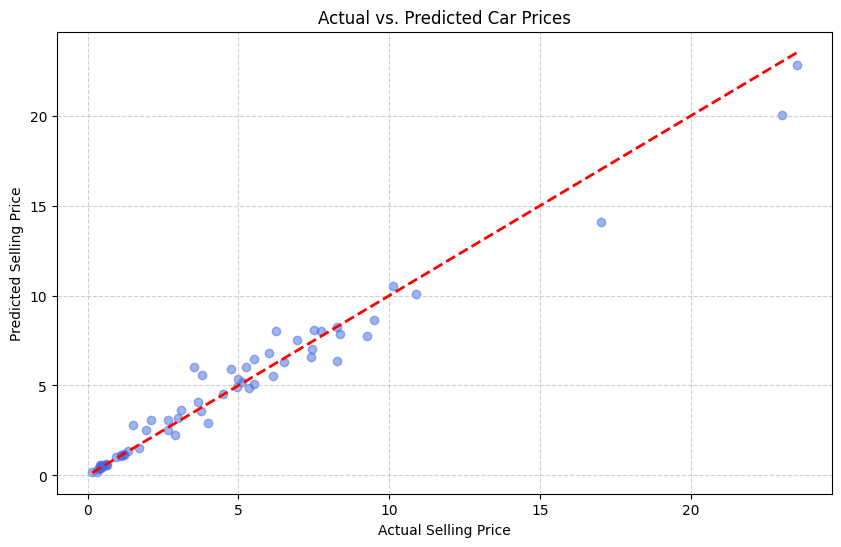

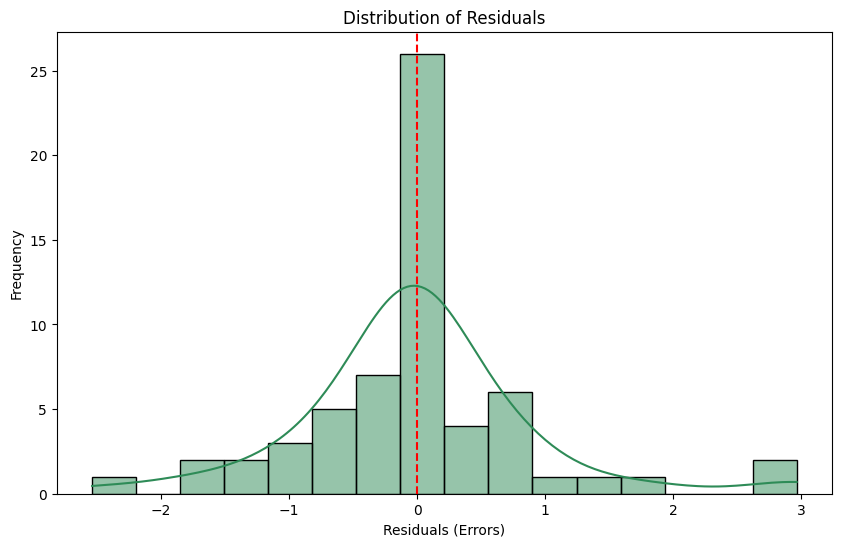

In [22]:
# Assuming your best model is stored in 'best_model' after GridSearchCV
# or simply using 'rf_model' as an example
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs. Predicted Car Prices')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() 

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='seagreen')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Residuals (Errors)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

  BASELINE MODELS


C:\Users\AKIB\AppData\Local\Temp\ipykernel_5140\264457125.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance, y=sorted_features, palette='viridis', ax=ax)


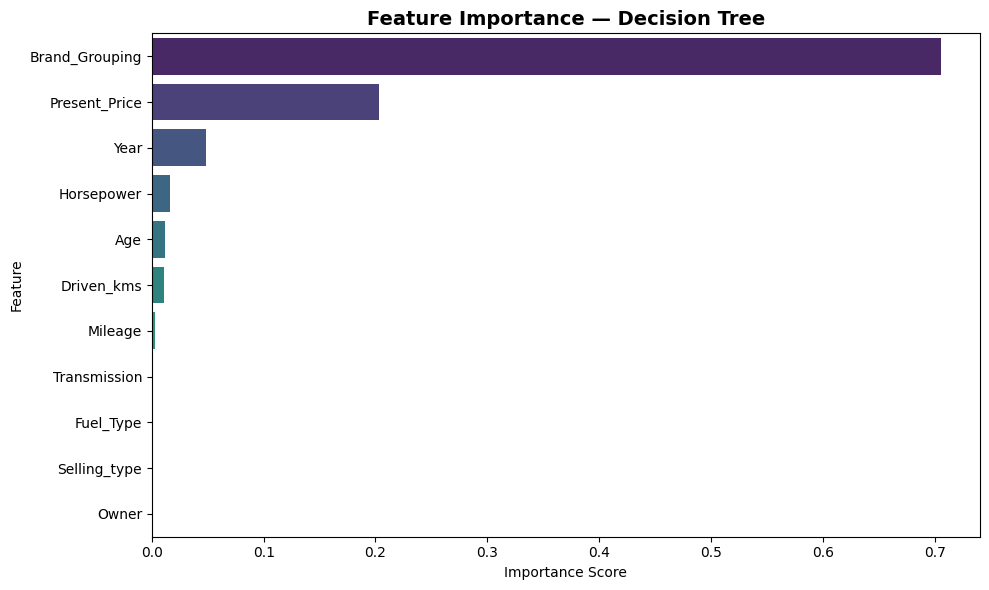

C:\Users\AKIB\AppData\Local\Temp\ipykernel_5140\264457125.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance, y=sorted_features, palette='viridis', ax=ax)


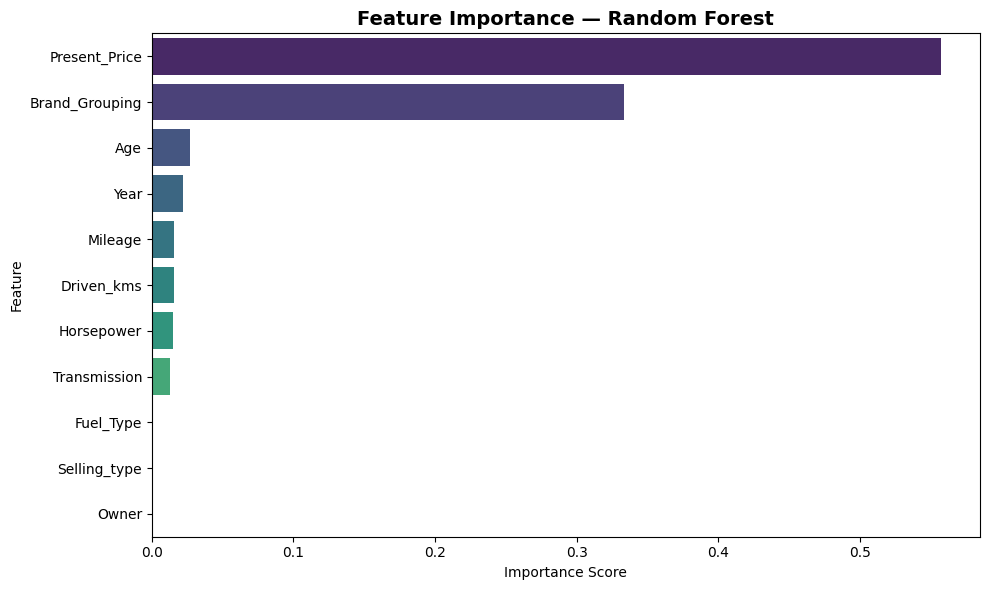

C:\Users\AKIB\AppData\Local\Temp\ipykernel_5140\264457125.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance, y=sorted_features, palette='viridis', ax=ax)


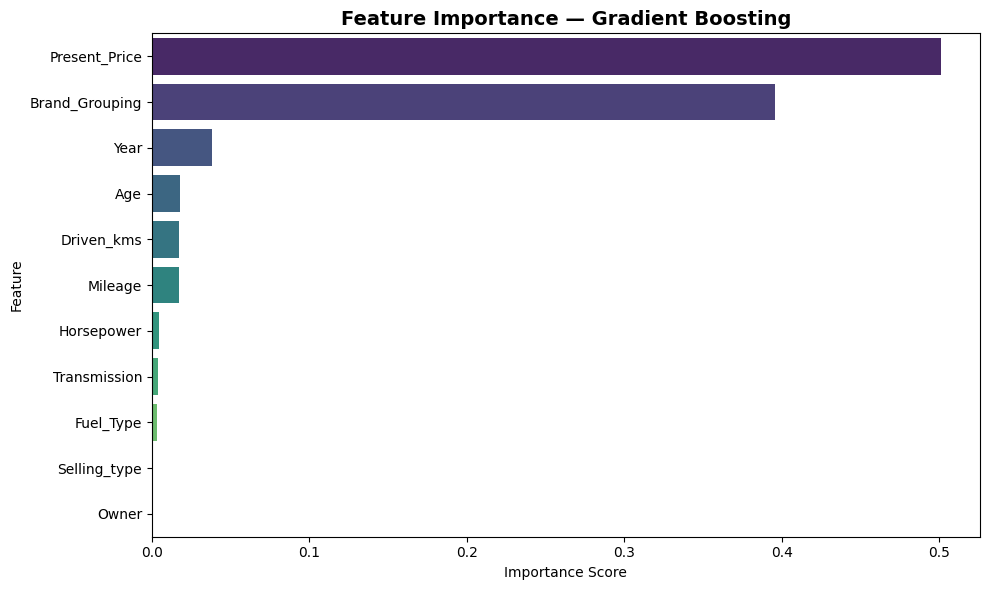

C:\Users\AKIB\AppData\Local\Temp\ipykernel_5140\264457125.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance, y=sorted_features, palette='viridis', ax=ax)


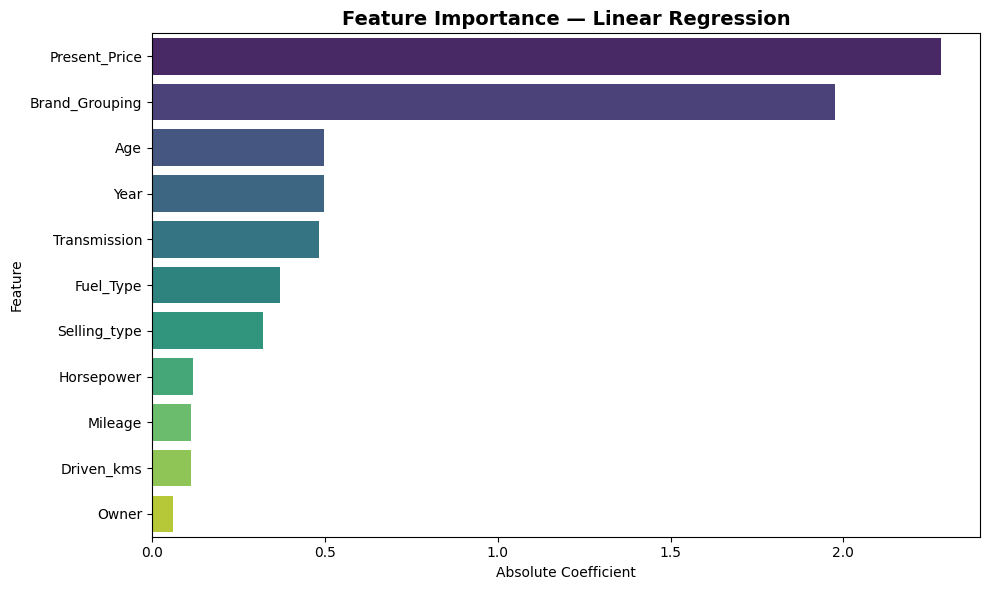

  TUNED MODELS (Best Estimators)


C:\Users\AKIB\AppData\Local\Temp\ipykernel_5140\264457125.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance, y=sorted_features, palette='viridis', ax=ax)


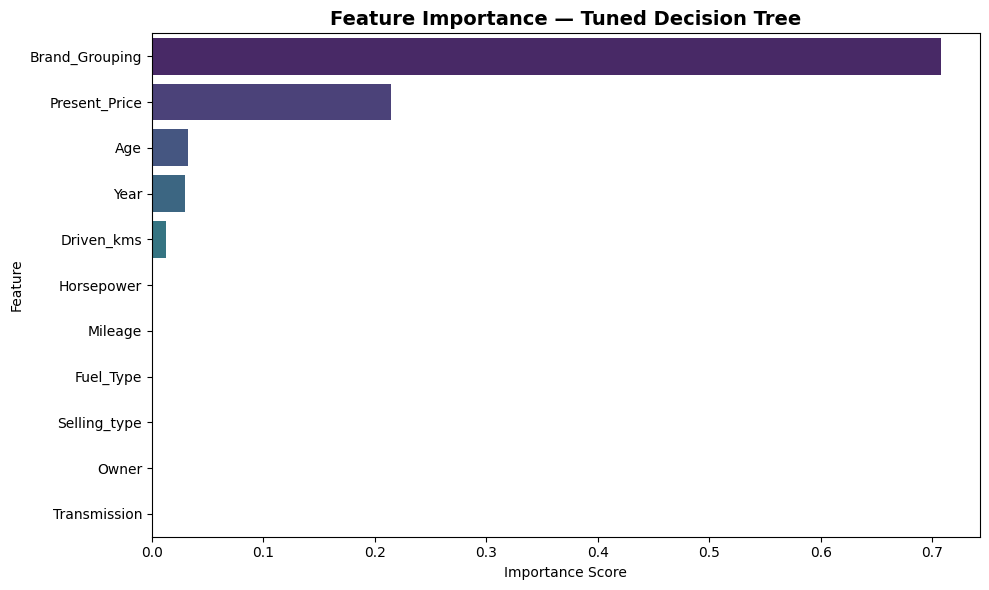

C:\Users\AKIB\AppData\Local\Temp\ipykernel_5140\264457125.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance, y=sorted_features, palette='viridis', ax=ax)


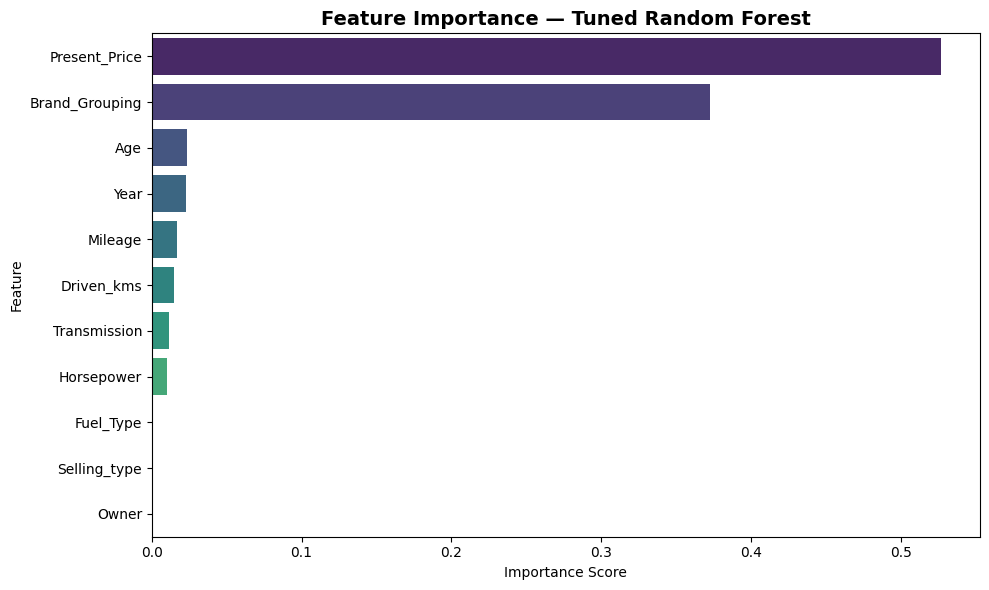

C:\Users\AKIB\AppData\Local\Temp\ipykernel_5140\264457125.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance, y=sorted_features, palette='viridis', ax=ax)


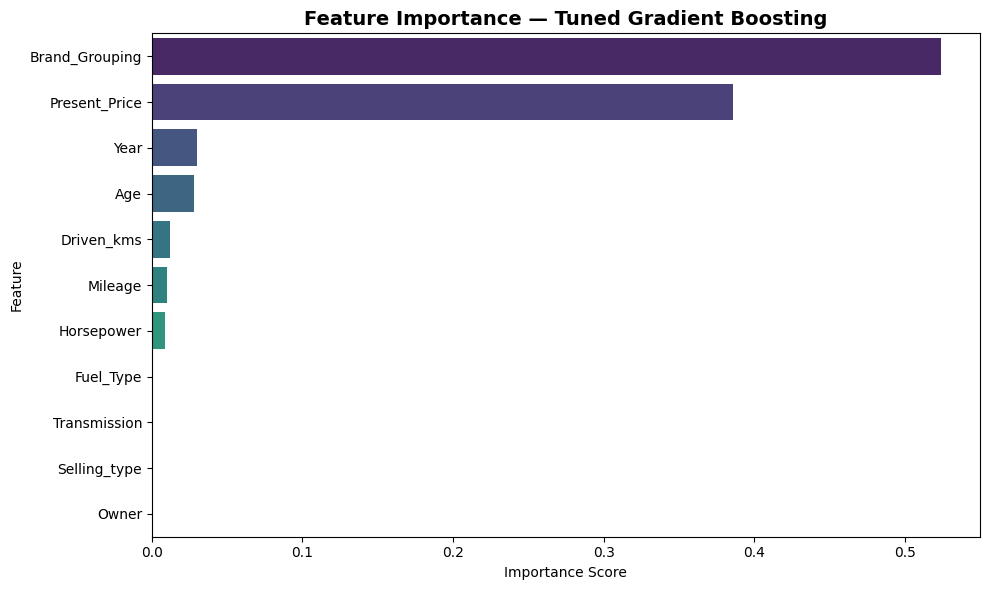

C:\Users\AKIB\AppData\Local\Temp\ipykernel_5140\264457125.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance, y=sorted_features, palette='viridis', ax=ax)


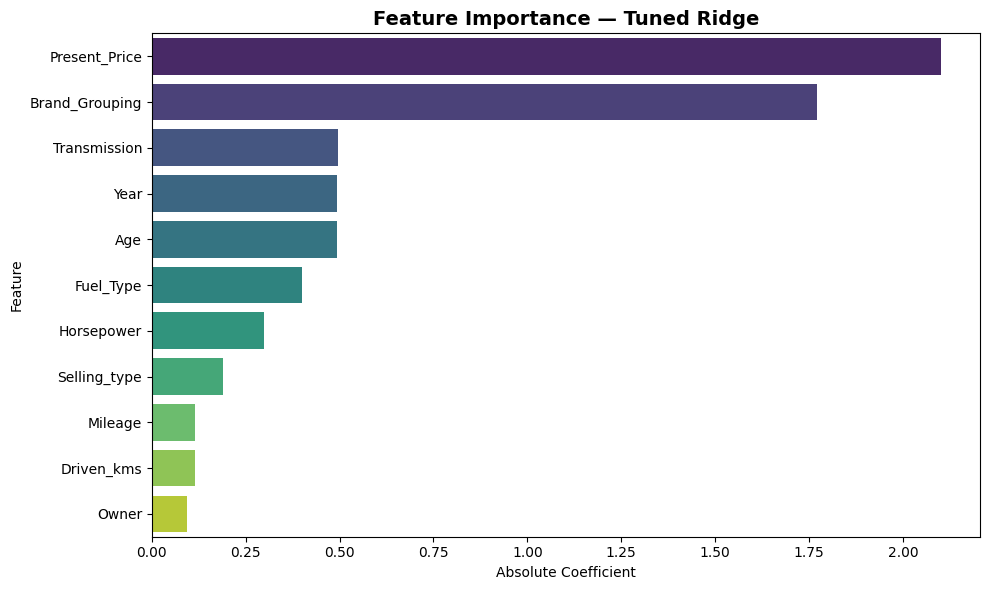

In [25]:
# ── Feature Importance / Coefficients for All Models ──────────────────────

feature_names = list(df.drop(columns=['Car_Name', 'Selling_Price', 'Depriciation Rate']).columns)

def plot_feature_importance(model, feature_names, model_name):
    """Plot feature importances for tree-based models, coefficients for linear models."""
    fig, ax = plt.subplots(figsize=(10, 6))

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        label = 'Importance Score'
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_)
        label = 'Absolute Coefficient'
    else:
        print(f"{model_name}: no feature importance or coefficients available.")
        return

    indices = np.argsort(importances)[::-1]
    sorted_features = [feature_names[i] for i in indices]
    sorted_importance = importances[indices]

    sns.barplot(x=sorted_importance, y=sorted_features, palette='viridis', ax=ax)
    ax.set_title(f'Feature Importance — {model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()


# ── 1. Baseline Models (from Cell 23) ─────────────────────────────────────
print("=" * 55)
print("  BASELINE MODELS")
print("=" * 55)

baseline_models = {
    "Decision Tree":       DecisionTreeRegressor(random_state=42),
    "Random Forest":       RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingRegressor(random_state=42),
    "Linear Regression":   LinearRegression(),
}

for name, mdl in baseline_models.items():
    mdl.fit(X_train, y_train)
    plot_feature_importance(mdl, feature_names, name)


# ── 2. Tuned Models (from Cell 25 GridSearchCV) ───────────────────────────
print("=" * 55)
print("  TUNED MODELS (Best Estimators)")
print("=" * 55)

tuned_models = {
    "Tuned Decision Tree":     grid_dt.best_estimator_,
    "Tuned Random Forest":     grid_rf.best_estimator_,
    "Tuned Gradient Boosting": grid_gb.best_estimator_,
    "Tuned Ridge":             grid_ridge.best_estimator_,
}

for name, mdl in tuned_models.items():
    plot_feature_importance(mdl, feature_names, name)
